#### 1.- Generar datos con corrimiento al rojo 

              x           y       x_min       y_min  distancia
0    119.230890  579.288083  117.329818  580.521079   2.265911
1    422.220515  790.006539  422.593633  790.593703   0.695686
2    527.551764  232.442030  527.214897  234.125321   1.716668
3    553.561207  250.692480  553.401672  250.228554   0.490591
4    164.865408  317.036148  163.894217  315.012720   2.244431
..          ...         ...         ...         ...        ...
995  291.119588  223.960654  292.132646  223.384889   1.165243
996  327.195186  212.322719  326.285122  211.262988   1.396869
997  676.276080  606.323256  675.406434  604.463694   2.052866
998  423.347295  792.873387  422.593633  790.593703   2.401034
999  531.221014  235.693333  532.188111  237.074011   1.685689

[1000 rows x 5 columns]
              x           y        v_x         v_y           v
0    119.230890  579.288083 -47.393945  -30.738734   56.489431
1    422.220515  790.006539  98.680145 -155.289933  183.991125
2    527.551764  232.442030 -1

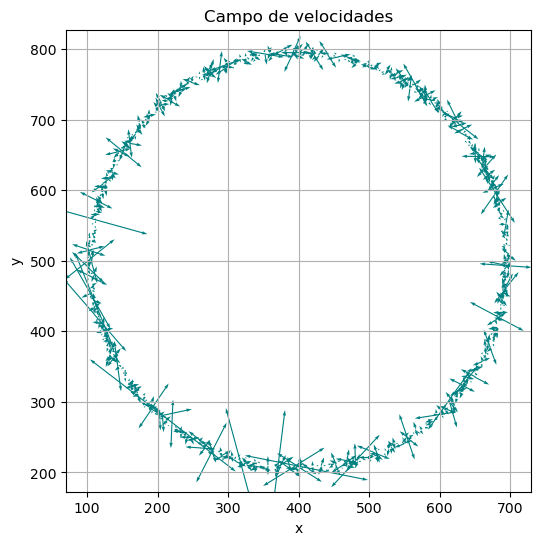

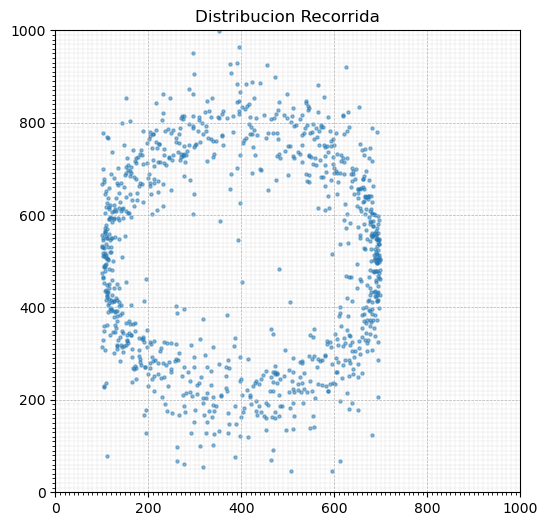

In [49]:
import sympy as owo
import numpy as uwu
import matplotlib as mlp
import matplotlib.pyplot as plt
from scipy import special
import math
import pandas as pd
import matplotlib.ticker as ticker
from mpl_toolkits.mplot3d import Axes3D

def spawn_puntos(n, d, t):
    if d == 2:
        x =  uwu.random.uniform(0, t, n) #Genera numeros aleatorios de 0 a t en x
        y = uwu.random.uniform(0, t ,n) #Genera numeros aleatorios de 0 a t en x
        puntos = uwu.vstack((x, y)).T   #Ordena los datos en una matriz de n x 2
    elif d == 3:
        x = uwu.random.uniform(0, t, n)
        y = uwu.random.uniform(0, t, n)
        z = uwu.random.uniform(0, t, n)
        puntos = uwu.vstack((x, y, z)).T #Ordena los datos en una matriz de n x 3
    return puntos

def grafica_2d(p,tam): #Grafica los puntos aleatorios en 2d
    plt.figure(figsize=(6,6))
    plt.scatter(p[:,0], p[:,1], alpha=0.5, s=5) #Toma los valores en x e y en el spawn de puntos y los grafica
    plt.xlim(0, tam) #Tam define el tamaño del grafico 
    plt.ylim(0, tam)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xticks(uwu.arange(0, tam+1, 200)) # Ejes cada 200 unidades
    plt.yticks(uwu.arange(0, tam+1, 200))
    ax = plt.gca()
    ax.set_xticks(uwu.arange(0, tam+1, 10), minor=True) # Cuadriculado de 10x10
    ax.set_yticks(uwu.arange(0, tam+1, 10), minor=True)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.3)
    plt.title("Distribucion Recorrida")
    plt.show()


def spawn_puntos_anillo(n, t, rm,rM,centro): #Distribucion de anillo
        #Centro debe ser un punto en el plano.
    
        angulos = uwu.random.uniform(0, 2*uwu.pi, n) #Genera angulos entre 0 a 2\pi
        radios = uwu.random.uniform(rm, rM, n)   # Generar radios de 0 a r, rm es el radio menor y rM el radio mayor del anillo
        x = radios * uwu.cos(angulos) #Transformacion de polares a cartesianas
        y = radios * uwu.sin(angulos)
        x += centro[0]  #Traslada el centro a las coordenadas de eleccion 
        y += centro[1]
        puntos = uwu.vstack((x, y)).T   #Ordena los datos en una matriz de n x 2
        return puntos

r1=290 #Radio menor
r2=300 #Radio mayor
num_p = 1000  # Cantidad de puntos
tam=1000   #Tamaño del grafico
centro=(400, 500) #Centro donde se generan los puntos del disco 
L=1000

Anillo= spawn_puntos_anillo(num_p, tam,r1,r2,centro) #Genera los puntos, segun las caracteristicas anteriores

#Calcular las distancias en la vecindad dicha 
Pos_x_or=[]
Pos_y_or=[]
Pos_x=[] #Guarda la posicion x de los puntos vecinos
Pos_y=[] #Guarda la posicion en y de los puntos vecinos 
Dis_Pos=[] #Guarda la distancia de los puntos vecinos

#Generacion de mapa de velocidades 

for i in range(num_p):
    Temp_x=[]
    Temp_y=[]
    Temp_d=[]
    for j in range(num_p):
        if i==j:
            continue
        if uwu.abs(Anillo[i,0]-Anillo[j,0])>L/10 or uwu.abs(Anillo[i,1]-Anillo[j,1])>L/10:
            continue
        dist = uwu.sqrt((Anillo[i, 0] - Anillo[j, 0]) ** 2 + (Anillo[i, 1] - Anillo[j, 1]) ** 2)
        if dist>L/10:
            continue
        Temp_x.append(Anillo[j,0])
        Temp_y.append(Anillo[j,1])
        Temp_d.append(dist)
    Matriz_Temp=uwu.vstack((Temp_x,Temp_y,Temp_d)).T
    indice_min = uwu.argmin(Matriz_Temp[:, 2])
    fila_dis_min = Matriz_Temp[indice_min]
    Pos_x_or.append(Anillo[i,0])
    Pos_y_or.append(Anillo[i,1])
    Pos_x.append(fila_dis_min[0]) 
    Pos_y.append(fila_dis_min[1])
    Dis_Pos.append(fila_dis_min[2])

Matriz_Datos = uwu.vstack((Pos_x_or, Pos_y_or,Pos_x,Pos_y,Dis_Pos)).T #Contiene el punto en la distribucion con su punto mas 
#cercano en la vecindad y la respectiva distancia
            
columnas = ["x", "y", "x_min", "y_min", "distancia"]

MD_Bonito = pd.DataFrame(Matriz_Datos, columns=columnas)

print(MD_Bonito)

#Matriz de velocidades 
Vel_x=[]
Vel_y=[]
Mag_vel=[]

for i in range(num_p):
    r_x=Matriz_Datos[i,2]-Matriz_Datos[i,0]
    r_y=Matriz_Datos[i,1]-Matriz_Datos[i,3]
    Mag_r=uwu.sqrt(r_x**2+r_y**2)
    r_x_N=r_x/Mag_r
    r_y_N=r_y/Mag_r
    vel=128/Mag_r
    v_x=vel*r_x_N
    v_y=vel*r_y_N
    Vel_x.append(v_x)
    Vel_y.append(v_y)
    Mag_vel.append(vel)

col_vel=["x","y","v_x","v_y","v"]

Matriz_Velocidades=uwu.vstack((Anillo[:,0] ,Anillo[:,1] ,Vel_x,Vel_y,Mag_vel)).T

Vel_Bonito=pd.DataFrame( Matriz_Velocidades, columns=col_vel)

print(Vel_Bonito)


# Graficar el campo vectorial
plt.figure(figsize=(6,6))
plt.quiver(Matriz_Velocidades[:,0], Matriz_Velocidades[:,1], Matriz_Velocidades[:,2], Matriz_Velocidades[:,3], color='teal')
plt.title('Campo de velocidades')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid(True)
plt.show()

#Anillo Achatado 
Anillo_Ach_y=[]
for i in range(num_p):
    y_ach=Anillo[i,1]+Matriz_Velocidades[i,2]
    Anillo_Ach_y.append(y_ach)

Anillo_Achatado=uwu.vstack((Anillo[:,0],Anillo_Ach_y)).T

#Grafica el nuevo Anillo

grafica_2d(Anillo_Achatado,tam)


#### 2.- Cambiar el código de la función de correlación con estimador de Landy-Salay, para que sea anisotrópico y guarde la componente de cada distancia en X y Y.

In [51]:
def Histo_distancias(dim_hist, num_p, p, bin_size): #Histograma para DD o RR Anisotropico 
    dim_hist_ext=int(2*dim_hist) #Extendemos la dimension de la matriz para contar tambien distancias negativas
    Hist_bi=uwu.zeros((dim_hist_ext,dim_hist_ext)) #Matriz de histograma
    for i in range(num_p):
        for j in range(i + 1, num_p):
            dist_x=p[i, 0] - p[j, 0] #Le quite el valor absoluto para que tambien cuente distancias negativas
            dist_y=p[i, 1] - p[j, 1]
            bin_x=int(dist_x / bin_size)
            bin_y=int(dist_y / bin_size)
            if bin_x >= dim_hist or bin_y>=dim_hist:  #Envia a His[0] todas las distancias que esten fuera de los bins analizados.
                Hist_bi[0,0] += 1
            else:
                bin_xn=dim_hist+bin_x #se desplazan los bines para acomodar las distancias negativas.
                bin_yn=dim_hist+bin_y
                Hist_bi[max(1, bin_xn),max(1,bin_yn)] += 1
        
                    
    return Hist_bi #Creo que este codigo ya me regresa el histograma bidimensional (igual checar).

def Histo_DR(dim_hist, num_pdatos,num_paleatorios, p_datos,p_aleatorios, bin_size):
    dim_hist_ext=int(2*dim_hist)
    Hist_biDR=uwu.zeros((dim_hist_ext,dim_hist_ext))#Histo para DR Anisotropico 
    for i in range(num_pdatos):
        for j in range(num_paleatorios):
            dist_x=p_datos[i, 0] - p_aleatorios[j, 0] #Histo_biDR
            dist_y= p_datos[i, 1] - p_aleatorios[j, 1]  
            bin_x = int(dist_x / bin_size)  # Calcula a qué bin pertenece.
            bin_y=int(dist_y / bin_size)
            if bin_x >= dim_hist or bin_y>=dim_hist:  #Envia a His[0] todas las distancias que esten fuera de los bins analizados.
                Hist_biDR[0,0] += 1
            else:
                bin_xn=dim_hist+bin_x
                bin_yn=dim_hist+bin_y
                Hist_biDR[max(1, bin_xn),max(1,bin_yn)] += 1

                
    return Hist_biDR

#Configuracion de bines:
bin_size = 3  # Tamaño del Bin
dim_hist = 300  # Número de Bins
num_bin_ciclos=int(2*dim_hist) #Uso el doble porque ahora las matrices resultantes tiene dimension 2(dim_hist)x2(dim_hist)
num_paleatorios=10000 #Numero de puntos aleatorios #Aumente el numero de puntos para evitar las divisiones entre cero del Histo de puntos random

puntos_RR = spawn_puntos(num_paleatorios, 2, tam) #Puntos aleatorios en la malla


Histo_PuntosRR = Histo_distancias(dim_hist, num_paleatorios, puntos_RR, bin_size) #Calcula los histogramas de la distribucion random en x,y
Anillo_DD=Histo_distancias(dim_hist, num_p, Anillo_Achatado, bin_size) #Calcula los histogramas DD en x,y
Anillo_DR= Histo_DR(dim_hist, num_p,num_paleatorios, Anillo_Achatado,puntos_RR, bin_size) #Calcula los histogramas DR en x,y

#Normalizamos los histogramas anisotropicos,
l_RR=0
for k in range(num_bin_ciclos): #Calcula el numero total de distancias calculadas (frecuencias).
    for l in range(num_bin_ciclos):
        l_RR=l_RR+Histo_PuntosRR[k,l]

Histo_PuntosRR_N=Histo_PuntosRR/l_RR # RR normalizado

l_DD=0
for k in range(num_bin_ciclos): #Calcula el numero total de distancias calculadas (frecuencias).
    for l in range(num_bin_ciclos):
        l_DD=l_DD+Anillo_DD[k,l]

Anillo_DD_N=Anillo_DD/l_DD # DD normalizado

l_DR=0
for k in range(num_bin_ciclos): #Calcula el numero total de distancias calculadas (frecuencias).
    for l in range(num_bin_ciclos):
        l_DR=l_DR+Anillo_DR[k,l]

Anillo_DR_N=Anillo_DR/l_DR # DR normalizado


LS_Anillo=uwu.empty((num_bin_ciclos,num_bin_ciclos))  #Guarda los datos de la funcion Peebles-Hausler 

for i in range(1,num_bin_ciclos):
    for j in range(1,num_bin_ciclos):
        LS_Anillo[i,j]=1+Anillo_DD_N[i,j]/Histo_PuntosRR_N[i,j]-2*Anillo_DR_N[i,j]/Histo_PuntosRR_N[i,j]

print(l_RR,l_DD,l_DR)
print(Histo_PuntosRR[1,1])

C:\Users\saibo\AppData\Local\Temp\ipykernel_6084\1415263655.py:79: RuntimeWarning: invalid value encountered in scalar divide
  LS_Anillo[i,j]=1+Anillo_DD_N[i,j]/Histo_PuntosRR_N[i,j]-2*Anillo_DR_N[i,j]/Histo_PuntosRR_N[i,j]


49995000.0 499500.0 10000000.0
1417.0


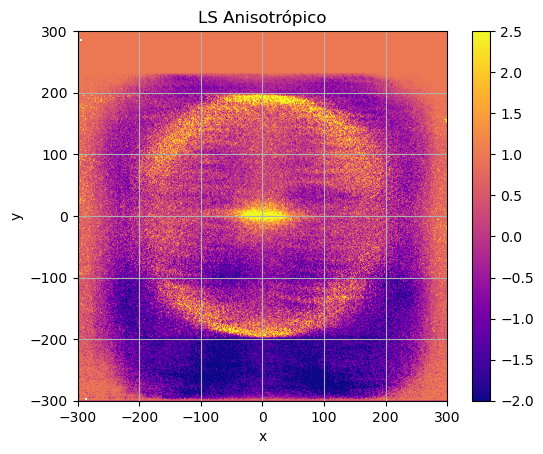

In [52]:


centro=[-300, 300, -300, 300] #Centra el imshow para observar la simetria de los cuadrantes 

plt.imshow(LS_Anillo, cmap='plasma', origin='lower', extent=centro, vmin=-2, vmax=2.5)
plt.colorbar()
plt.title("LS Anisotrópico")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()
